In [80]:
import pandas as pd
import numpy as np

In [81]:
df=pd.read_csv('training_set_features.csv')
label=pd.read_csv('training_set_labels.csv')

In [82]:
df.columns

Index(['respondent_id', 'h1n1_concern', 'h1n1_knowledge',
       'behavioral_antiviral_meds', 'behavioral_avoidance',
       'behavioral_face_mask', 'behavioral_wash_hands',
       'behavioral_large_gatherings', 'behavioral_outside_home',
       'behavioral_touch_face', 'doctor_recc_h1n1', 'doctor_recc_seasonal',
       'chronic_med_condition', 'child_under_6_months', 'health_worker',
       'health_insurance', 'opinion_h1n1_vacc_effective', 'opinion_h1n1_risk',
       'opinion_h1n1_sick_from_vacc', 'opinion_seas_vacc_effective',
       'opinion_seas_risk', 'opinion_seas_sick_from_vacc', 'age_group',
       'education', 'race', 'sex', 'income_poverty', 'marital_status',
       'rent_or_own', 'employment_status', 'hhs_geo_region', 'census_msa',
       'household_adults', 'household_children', 'employment_industry',
       'employment_occupation'],
      dtype='object')

In [83]:
label.columns

Index(['respondent_id', 'h1n1_vaccine', 'seasonal_vaccine'], dtype='object')

In [84]:
df.head()

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,income_poverty,marital_status,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation
0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,Below Poverty,Not Married,Own,Not in Labor Force,oxchjgsf,Non-MSA,0.0,0.0,NaN,NaN
1,1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,...,Below Poverty,Not Married,Rent,Employed,bhuqouqj,"MSA, Not Principle City",0.0,0.0,pxcmvdjn,xgwztkwe
2,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,"<= $75,000, Above Poverty",Not Married,Own,Employed,qufhixun,"MSA, Not Principle City",2.0,0.0,rucpziij,xtkaffoo
3,3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,Below Poverty,Not Married,Rent,Not in Labor Force,lrircsnp,"MSA, Principle City",0.0,0.0,NaN,NaN
4,4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,...,"<= $75,000, Above Poverty",Married,Own,Employed,qufhixun,"MSA, Not Principle City",1.0,0.0,wxleyezf,emcorrxb


In [85]:
df['h1n1_concern'].value_counts()

h1n1_concern
2.0    10575
1.0     8153
3.0     4591
0.0     3296
Name: count, dtype: int64

In [86]:
df['employment_status'].value_counts()

employment_status
Employed              13560
Not in Labor Force    10231
Unemployed             1453
Name: count, dtype: int64

In [87]:
df['income_poverty'].value_counts()


income_poverty
<= $75,000, Above Poverty    12777
> $75,000                     6810
Below Poverty                 2697
Name: count, dtype: int64

In [88]:
df['marital_status'].value_counts()

marital_status
Married        13555
Not Married    11744
Name: count, dtype: int64

In [89]:
df['rent_or_own'].value_counts()

rent_or_own
Own     18736
Rent     5929
Name: count, dtype: int64

In [90]:
df['employment_status'].value_counts()

employment_status
Employed              13560
Not in Labor Force    10231
Unemployed             1453
Name: count, dtype: int64

In [91]:
df['hhs_geo_region'].value_counts()

hhs_geo_region
lzgpxyit    4297
fpwskwrf    3265
qufhixun    3102
oxchjgsf    2859
kbazzjca    2858
bhuqouqj    2846
mlyzmhmf    2243
lrircsnp    2078
atmpeygn    2033
dqpwygqj    1126
Name: count, dtype: int64

In [92]:
df['census_msa'].value_counts()

census_msa
MSA, Not Principle  City    11645
MSA, Principle City          7864
Non-MSA                      7198
Name: count, dtype: int64

In [93]:
df['employment_industry'].value_counts()

employment_industry
fcxhlnwr    2468
wxleyezf    1804
ldnlellj    1231
pxcmvdjn    1037
atmlpfrs     926
arjwrbjb     871
xicduogh     851
mfikgejo     614
vjjrobsf     527
rucpziij     523
xqicxuve     511
saaquncn     338
cfqqtusy     325
nduyfdeo     286
mcubkhph     275
wlfvacwt     215
dotnnunm     201
haxffmxo     148
msuufmds     124
phxvnwax      89
qnlwzans      13
Name: count, dtype: int64

In [94]:
df['employment_occupation'].value_counts()

employment_occupation
xtkaffoo    1778
mxkfnird    1509
emcorrxb    1270
cmhcxjea    1247
xgwztkwe    1082
hfxkjkmi     766
qxajmpny     548
xqwwgdyp     485
kldqjyjy     469
uqqtjvyb     452
tfqavkke     388
ukymxvdu     372
vlluhbov     354
oijqvulv     344
ccgxvspp     341
bxpfxfdn     331
haliazsg     296
rcertsgn     276
xzmlyyjv     248
dlvbwzss     227
hodpvpew     208
dcjcmpih     148
pvmttkik      98
Name: count, dtype: int64

In [95]:
label['h1n1_vaccine'].value_counts()

h1n1_vaccine
0    21033
1     5674
Name: count, dtype: int64

In [96]:
label['seasonal_vaccine'].value_counts()

seasonal_vaccine
0    14272
1    12435
Name: count, dtype: int64

<!-- ### Missing Values -->

In [97]:
features_with_na = [features for features in df.columns if df[features].isnull().sum()>0]

print('Total number of features with missing values: ', len(features_with_na))
for feature in features_with_na:
    print(feature, np.round(df[feature].isnull().sum()), 'total missing values' , np.round(df[feature].isnull().mean()*100, 4), '% of total values')

Total number of features with missing values:  30
h1n1_concern 92 total missing values 0.3445 % of total values
h1n1_knowledge 116 total missing values 0.4343 % of total values
behavioral_antiviral_meds 71 total missing values 0.2658 % of total values
behavioral_avoidance 208 total missing values 0.7788 % of total values
behavioral_face_mask 19 total missing values 0.0711 % of total values
behavioral_wash_hands 42 total missing values 0.1573 % of total values
behavioral_large_gatherings 87 total missing values 0.3258 % of total values
behavioral_outside_home 82 total missing values 0.307 % of total values
behavioral_touch_face 128 total missing values 0.4793 % of total values
doctor_recc_h1n1 2160 total missing values 8.0878 % of total values
doctor_recc_seasonal 2160 total missing values 8.0878 % of total values
chronic_med_condition 971 total missing values 3.6358 % of total values
child_under_6_months 820 total missing values 3.0704 % of total values
health_worker 804 total missing 

In [98]:
import matplotlib.pyplot as plt

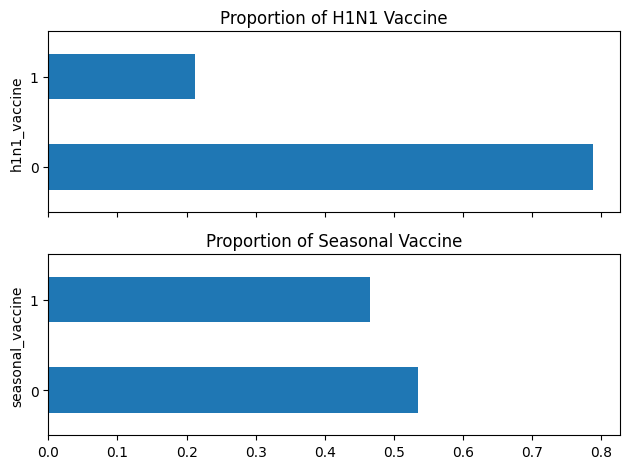

In [99]:
fig, ax = plt.subplots(2, 1, sharex=True)

n_obs = label.shape[0]

(
    label["h1n1_vaccine"]
    .value_counts()
    .div(n_obs)
    .plot.barh(title="Proportion of H1N1 Vaccine", ax=ax[0])
)
ax[0].set_ylabel("h1n1_vaccine")

(
    label["seasonal_vaccine"]
    .value_counts()
    .div(n_obs)
    .plot.barh(title="Proportion of Seasonal Vaccine", ax=ax[1])
)
ax[1].set_ylabel("seasonal_vaccine")

fig.tight_layout()

<!-- ## correlation between both labels -->

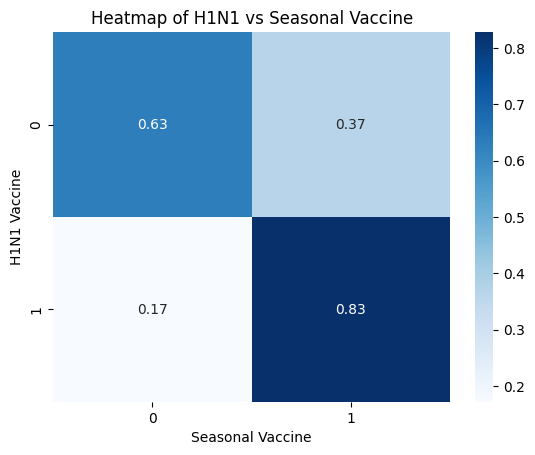

In [100]:
import seaborn as sns

sns.heatmap(
    pd.crosstab(label['h1n1_vaccine'], label['seasonal_vaccine'], normalize='index'),
    annot=True, cmap='Blues'
)
plt.title('Heatmap of H1N1 vs Seasonal Vaccine')
plt.xlabel('Seasonal Vaccine')
plt.ylabel('H1N1 Vaccine')
plt.show()

<!-- # both the rows are corellated so have to consider as a multilabel classification -->

In [102]:
Joined_data = df.merge(label)

In [103]:
Joined_data.columns

Index(['respondent_id', 'h1n1_concern', 'h1n1_knowledge',
       'behavioral_antiviral_meds', 'behavioral_avoidance',
       'behavioral_face_mask', 'behavioral_wash_hands',
       'behavioral_large_gatherings', 'behavioral_outside_home',
       'behavioral_touch_face', 'doctor_recc_h1n1', 'doctor_recc_seasonal',
       'chronic_med_condition', 'child_under_6_months', 'health_worker',
       'health_insurance', 'opinion_h1n1_vacc_effective', 'opinion_h1n1_risk',
       'opinion_h1n1_sick_from_vacc', 'opinion_seas_vacc_effective',
       'opinion_seas_risk', 'opinion_seas_sick_from_vacc', 'age_group',
       'education', 'race', 'sex', 'income_poverty', 'marital_status',
       'rent_or_own', 'employment_status', 'hhs_geo_region', 'census_msa',
       'household_adults', 'household_children', 'employment_industry',
       'employment_occupation', 'h1n1_vaccine', 'seasonal_vaccine'],
      dtype='object')

In [ ]:
Joined_data.shape


(26707, 38)

In [105]:
counts = (
    Joined_data[["h1n1_concern", "h1n1_vaccine"]]
    .groupby(["h1n1_concern", "h1n1_vaccine"])
    .size()
    .unstack("h1n1_vaccine")
)
counts

h1n1_vaccine,0,1
h1n1_concern,,
0.0,2849,447
1.0,6756,1397
2.0,8102,2473
3.0,3250,1341


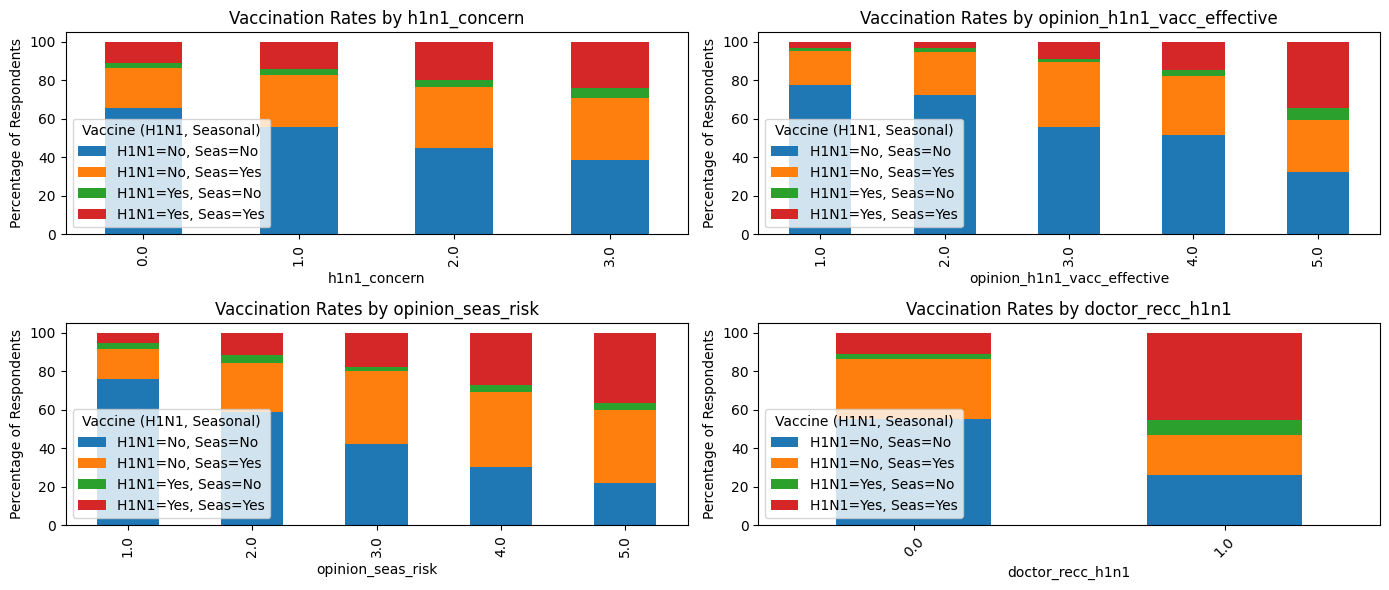

In [ ]:
def plot_vaccine_rates_by_feature(feature, df, ax):
    """Helper function to plot vaccination rates for a given feature."""
    ct = pd.crosstab(df[feature], [df['h1n1_vaccine'], df['seasonal_vaccine']], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=ax, figsize=(14, 6))
    ax.set_title(f'Vaccination Rates by {feature}')
    ax.set_ylabel('Percentage of Respondents')
    ax.legend(title='Vaccine (H1N1, Seasonal)', labels=['H1N1=No, Seas=No', 'H1N1=No, Seas=Yes', 'H1N1=Yes, Seas=No', 'H1N1=Yes, Seas=Yes'])
    plt.xticks(rotation=45)

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
      
plot_vaccine_rates_by_feature('h1n1_concern', Joined_data, axes[0, 0])
plot_vaccine_rates_by_feature('opinion_h1n1_vacc_effective', Joined_data, axes[0, 1])
plot_vaccine_rates_by_feature('opinion_seas_risk', Joined_data, axes[1, 0])
plot_vaccine_rates_by_feature('doctor_recc_h1n1', Joined_data, axes[1, 1])

plt.tight_layout()
plt.show()

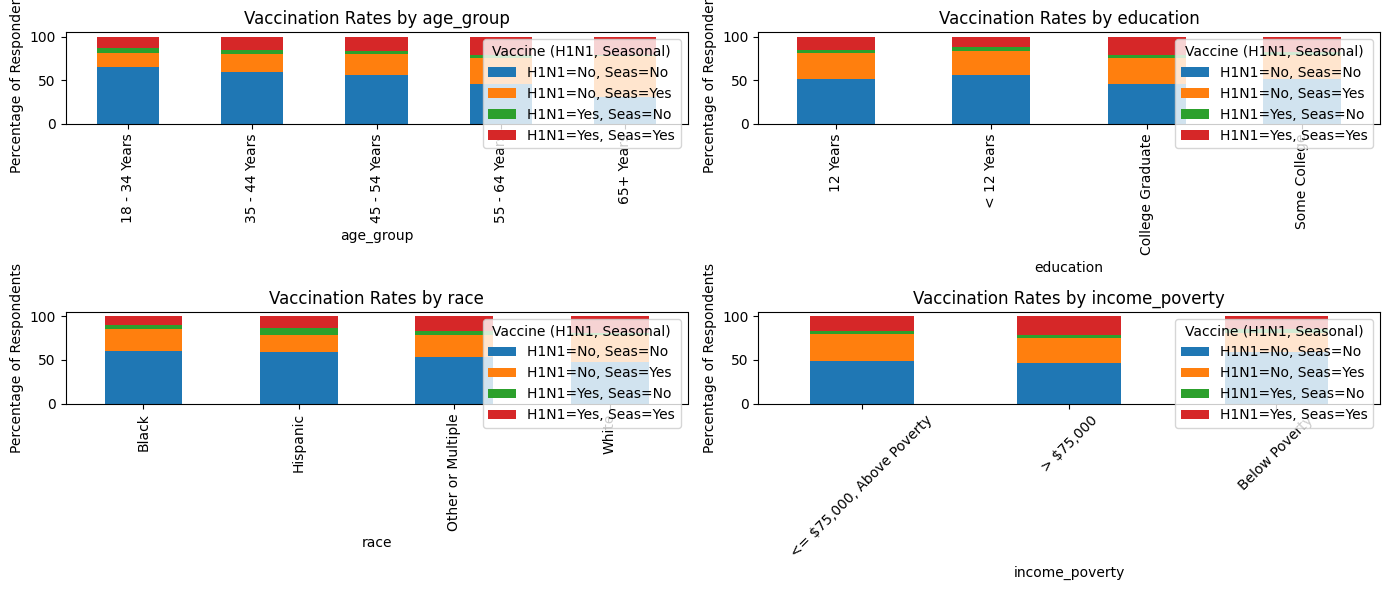

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

plot_vaccine_rates_by_feature('age_group', Joined_data, axes[0, 0])
plot_vaccine_rates_by_feature('education', Joined_data, axes[0, 1])combined_label = combined_label[mask]
plot_vaccine_rates_by_feature('race', Joined_data, axes[1, 0])
plot_vaccine_rates_by_feature('income_poverty', Joined_data, axes[1, 1])

plt.tight_layout()
plt.show()

In [107]:
def vaccination_rate_plot(col, target, data, ax=None):
    """Stacked bar chart of vaccination rate for `target` against
    `col`.

    Args:
        col (string): column name of feature variable
        target (string): column name of target variable
        data (pandas DataFrame): dataframe that contains columns
            `col` and `target`
        ax (matplotlib axes object, optional): matplotlib axes
            object to attach plot to
    """
    counts = Joined_data[[target, col]].groupby([target, col]).size().unstack(target)
    group_counts = counts.sum(axis="columns")
    props = counts.div(group_counts, axis="index")

    props.plot(kind="barh", stacked=True, ax=ax)
    ax.invert_yaxis()
    ax.legend().remove()

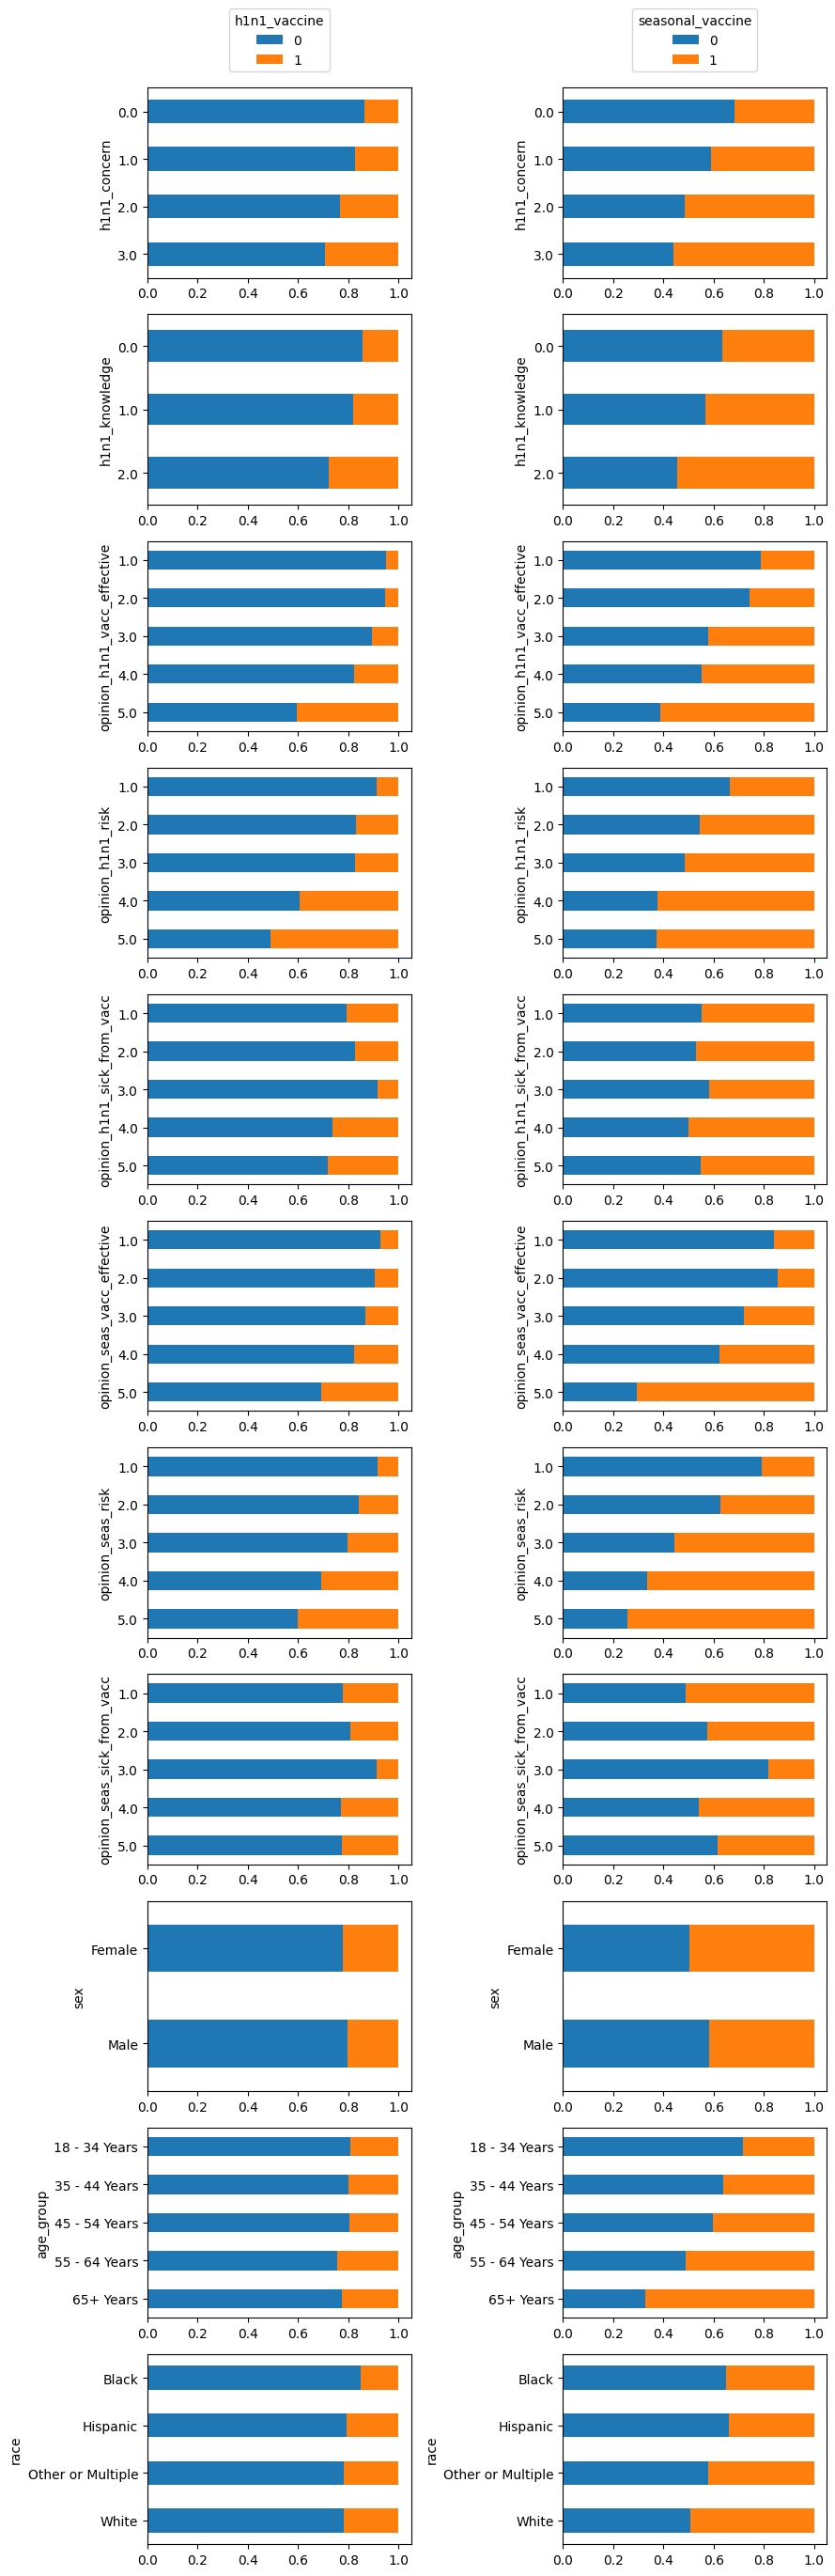

In [109]:
cols_to_plot = [
    "h1n1_concern",
    "h1n1_knowledge",
    "opinion_h1n1_vacc_effective",
    "opinion_h1n1_risk",
    "opinion_h1n1_sick_from_vacc",
    "opinion_seas_vacc_effective",
    "opinion_seas_risk",
    "opinion_seas_sick_from_vacc",
    "sex",
    "age_group",
    "race",
]

fig, ax = plt.subplots(len(cols_to_plot), 2, figsize=(9, len(cols_to_plot) * 2.5))
for idx, col in enumerate(cols_to_plot):
    vaccination_rate_plot(col, "h1n1_vaccine", Joined_data, ax=ax[idx, 0])
    vaccination_rate_plot(col, "seasonal_vaccine", Joined_data, ax=ax[idx, 1])

ax[0, 0].legend(loc="lower center", bbox_to_anchor=(0.5, 1.05), title="h1n1_vaccine")
ax[0, 1].legend(loc="lower center", bbox_to_anchor=(0.5, 1.05), title="seasonal_vaccine")
fig.tight_layout()

In [110]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier

from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split

from sklearn.metrics import roc_curve, roc_auc_score

RANDOM_SEED = 6 

In [111]:
df.dtypes != "object"

respondent_id                   True
h1n1_concern                    True
h1n1_knowledge                  True
behavioral_antiviral_meds       True
behavioral_avoidance            True
behavioral_face_mask            True
behavioral_wash_hands           True
behavioral_large_gatherings     True
behavioral_outside_home         True
behavioral_touch_face           True
doctor_recc_h1n1                True
doctor_recc_seasonal            True
chronic_med_condition           True
child_under_6_months            True
health_worker                   True
health_insurance                True
opinion_h1n1_vacc_effective     True
opinion_h1n1_risk               True
opinion_h1n1_sick_from_vacc     True
opinion_seas_vacc_effective     True
opinion_seas_risk               True
opinion_seas_sick_from_vacc     True
age_group                      False
education                      False
race                           False
sex                            False
income_poverty                 False
m

In [112]:
numeric_cols = df.columns[df.dtypes != "object"].values
print(numeric_cols)

['respondent_id' 'h1n1_concern' 'h1n1_knowledge'
 'behavioral_antiviral_meds' 'behavioral_avoidance' 'behavioral_face_mask'
 'behavioral_wash_hands' 'behavioral_large_gatherings'
 'behavioral_outside_home' 'behavioral_touch_face' 'doctor_recc_h1n1'
 'doctor_recc_seasonal' 'chronic_med_condition' 'child_under_6_months'
 'health_worker' 'health_insurance' 'opinion_h1n1_vacc_effective'
 'opinion_h1n1_risk' 'opinion_h1n1_sick_from_vacc'
 'opinion_seas_vacc_effective' 'opinion_seas_risk'
 'opinion_seas_sick_from_vacc' 'household_adults' 'household_children']


In [113]:
# chain preprocessing into a Pipeline object
# each step is a tuple of (name you chose, sklearn transformer)
numeric_preprocessing_steps = Pipeline(
    [
        ("standard_scaler", StandardScaler()),
        ("simple_imputer", SimpleImputer(strategy="median")),
    ]
)

# create the preprocessor stage of final pipeline
# each entry in the transformer list is a tuple of
# (name you choose, sklearn transformer, list of columns)
preprocessor = ColumnTransformer(
    transformers=[("numeric", numeric_preprocessing_steps, numeric_cols)],
    remainder="drop",
)

In [114]:
estimators = MultiOutputClassifier(estimator=LogisticRegression(penalty="l2", C=1))


In [115]:
full_pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("estimators", estimators),
    ]
)

In [116]:
full_pipeline

,steps,"[('preprocessor', ...), ('estimators', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [117]:
label.isna().sum()


respondent_id       0
h1n1_vaccine        0
seasonal_vaccine    0
dtype: int64

In [122]:
label

,respondent_id,h1n1_vaccine,seasonal_vaccine
0,0,0,0
1,1,0,1
2,2,0,0
3,3,0,1
4,4,0,0
...,...,...,...
26702,26702,0,0
26703,26703,0,0
26704,26704,0,1
26705,26705,0,0


In [123]:
#remove respondentsid column
label = label.drop(columns=['respondent_id'])

In [125]:
# Stratify on a single target (e.g. h1n1_vaccine) to avoid groups with only one sample
X_train, X_eval, y_train, y_eval = train_test_split(
    df,
    label,
    test_size=0.33,
    shuffle=True,
    stratify=label,
    
    random_state=RANDOM_SEED,
)

In [126]:
%%time

# Train model
full_pipeline.fit(X_train, y_train)

# Predict on evaluation set
# This competition wants probabilities, not labels
preds = full_pipeline.predict_proba(X_eval)
preds

CPU times: user 1.33 s, sys: 10.3 ms, total: 1.34 s
Wall time: 338 ms


[array([[0.70772411, 0.29227589],
        [0.90255907, 0.09744093],
        [0.84342896, 0.15657104],
        ...,
        [0.92337364, 0.07662636],
        [0.89677676, 0.10322324],
        [0.92791261, 0.07208739]], shape=(8814, 2)),
 array([[0.52190254, 0.47809746],
        [0.62112122, 0.37887878],
        [0.36294685, 0.63705315],
        ...,
        [0.85929411, 0.14070589],
        [0.78104136, 0.21895864],
        [0.1510818 , 0.8489182 ]], shape=(8814, 2))]

In [127]:

print("test_probas[0].shape", preds[0].shape)
print("test_probas[1].shape", preds[1].shape)

test_probas[0].shape (8814, 2)
test_probas[1].shape (8814, 2)


In [129]:
y_preds = pd.DataFrame(
    {
        "h1n1_vaccine": preds[0][:, 1],
        "seasonal_vaccine": preds[1][:, 1],
    },
    index=y_eval.index,
)
print("y_preds.shape:", y_preds.shape)
y_preds.head()

y_preds.shape: (8814, 2)


,h1n1_vaccine,seasonal_vaccine
6728,0.292276,0.478097
16516,0.097441,0.378879
3106,0.156571,0.637053
16981,0.660799,0.856437
19111,0.283215,0.773567


In [130]:
def plot_roc(y_true, y_score, label_name, ax):
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    ax.plot(fpr, tpr)
    ax.plot([0, 1], [0, 1], color="grey", linestyle="--")
    ax.set_ylabel("TPR")
    ax.set_xlabel("FPR")
    ax.set_title(f"{label_name}: AUC = {roc_auc_score(y_true, y_score):.4f}")

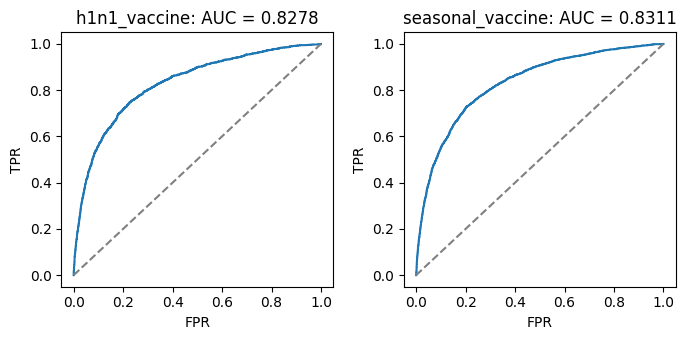

In [132]:
fig, ax = plt.subplots(1, 2, figsize=(7, 3.5))

plot_roc(y_eval["h1n1_vaccine"], y_preds["h1n1_vaccine"], "h1n1_vaccine", ax=ax[0])
plot_roc(
    y_eval["seasonal_vaccine"], y_preds["seasonal_vaccine"], "seasonal_vaccine", ax=ax[1]
)
fig.tight_layout()

In [133]:
roc_auc_score(y_eval, y_preds)

0.8294188419198878

In [135]:
%%time 

full_pipeline.fit(df, label)

None 

CPU times: user 7.14 s, sys: 55.2 ms, total: 7.2 s
Wall time: 1.02 s


## Predictions

In [ ]:
submission_df.head()test_features_df = pd.read_csv("test_set_features.csv", index_col="respondent_id")

In [140]:
# ensure respondent_id is a column so the preprocessor finds the same columns as during training
if "respondent_id" not in test_features_df.columns:
	test_features_df = test_features_df.reset_index()

test_probas = full_pipeline.predict_proba(test_features_df)
test_probas

[array([[0.87358115, 0.12641885],
        [0.94515761, 0.05484239],
        [0.63056283, 0.36943717],
        ...,
        [0.80731749, 0.19268251],
        [0.95020593, 0.04979407],
        [0.38936599, 0.61063401]], shape=(26708, 2)),
 array([[0.57783382, 0.42216618],
        [0.92987557, 0.07012443],
        [0.36647319, 0.63352681],
        ...,
        [0.6108389 , 0.3891611 ],
        [0.69093304, 0.30906696],
        [0.3695974 , 0.6304026 ]], shape=(26708, 2))]

In [142]:
submission_df = pd.read_csv("submission_format.csv", index_col="respondent_id")

In [143]:
submission_df.head()

,h1n1_vaccine,seasonal_vaccine
respondent_id,,
26707,0.5,0.7
26708,0.5,0.7
26709,0.5,0.7
26710,0.5,0.7
26711,0.5,0.7


In [145]:
# Ensure the test_features_df index matches submission_df index (respondent_id)
if "respondent_id" in test_features_df.columns:
	test_features_df = test_features_df.set_index("respondent_id")

# Make sure we have the rows in the same order
np.testing.assert_array_equal(test_features_df.index.values, submission_df.index.values)

# Save predictions to submission data frame
submission_df["h1n1_vaccine"] = test_probas[0][:, 1]
submission_df["seasonal_vaccine"] = test_probas[1][:, 1]

submission_df.head()

,h1n1_vaccine,seasonal_vaccine
respondent_id,,
26707,0.126419,0.422166
26708,0.054842,0.070124
26709,0.369437,0.633527
26710,0.462410,0.800867
26711,0.285210,0.630794


In [146]:
submission_df.to_csv("my_submission.csv", index=True)

In [147]:

!head my_submission.csv

respondent_id,h1n1_vaccine,seasonal_vaccine
26707,0.12641884641091555,0.42216617802105333
26708,0.054842393451766266,0.07012443127109677
26709,0.3694371664061131,0.6335268063770605
26710,0.4624103765568017,0.8008671778598495
26711,0.2852095770018641,0.6307939637614174
26712,0.406152923552495,0.8885559609658712
26713,0.27128335488054767,0.3269039095592561
26714,0.11765517150299366,0.2372212477767441
26715,0.03039546416442501,0.14650569135757827
